In [206]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Настройки графиков
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

# Игнорировать предупреждения
import warnings
warnings.filterwarnings('ignore')

import requests

import os
os.makedirs('charts', exist_ok=True)

In [207]:
from dotenv import load_dotenv

load_dotenv()  # загружаются переменные из файла

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

# resp = requests.get(f'{API_URL}/registrations', params={'begin': DATE_BEGIN, 'end': DATE_END})

In [208]:
# df_v = pd.read_csv('./visits_1k.csv')
# df_r = pd.read_csv('./regs_1k.csv')

In [209]:
# df_v

In [210]:
# df_r

In [211]:
# df_v.describe()

In [212]:
# df_r.describe()

In [213]:
def get_df_based_on_env(path):
    return pd.DataFrame(requests.get(f'{API_URL}/{path}', params={'begin': DATE_BEGIN, 'end': DATE_END}).json())

df_r_date = get_df_based_on_env('registrations')
df_v_date = get_df_based_on_env('visits')

In [214]:
df_r_date.to_csv('res_2023-03-01_2023-09-01')
df_v_date.to_csv('vis_2023-03-01_2023-09-01')

In [215]:
df_r_date 

,datetime,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google
...,...,...,...,...,...
21831,2023-08-31T07:32:08,a94b4a28-f25c-433c-b4ef-85af7d5b0c11,ikelley@example.net,ios,apple
21832,2023-08-31T23:25:50,fc709c6b-528b-40d8-8980-c2c278e5a628,brittanycox@example.net,ios,apple
21833,2023-08-31T19:29:18,11e32805-7571-4108-8e50-e211d051bf7e,aryan@example.net,ios,apple
21834,2023-08-31T19:38:54,bce7b818-768b-434a-b6af-573cd60bff7f,emartinez@example.net,ios,email


In [216]:
df_v_date

,visit_id,platform,user_agent,datetime
0,60db9b85-12b3-447a-b93d-be177181f732,web,Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7...,2023-04-05T15:03:40
1,9e73a9ba-0c42-4a4d-bf8a-bde5bbe655ed,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T10:59:38
2,9e73a9ba-0c42-4a4d-bf8a-bde5bbe655ed,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-03T14:53:40
3,16dea4d8-2fb7-4c6b-b953-dc2b9686daf5,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T03:12:36
4,166bc823-c133-41fa-913d-3dbc495b2770,web,Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7...,2023-04-05T11:48:56
...,...,...,...,...
263454,8afe396f-48fb-4167-805e-2c1fd0d02d66,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:15....,2023-04-05T16:11:35
263455,8afe396f-48fb-4167-805e-2c1fd0d02d66,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:15....,2023-04-03T22:10:34
263456,d42c57ef-708f-4482-b1b2-4202bbdc6711,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T11:17:12
263457,af71107e-68e9-4dd9-a47b-b16ff5090ff3,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T00:28:53


In [217]:
df_r_date['user_id'].unique().size
#21836 строк всего было

21836

In [218]:
df_v_date['user_agent'].str.contains('bot').sum()

np.int64(7382)

In [219]:
df_v_nobot = df_v_date[~df_v_date['user_agent'].str.contains('bot')]

In [220]:
df_v_nobot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256077 entries, 0 to 263458
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   visit_id    256077 non-null  object
 1   platform    256077 non-null  object
 2   user_agent  256077 non-null  object
 3   datetime    256077 non-null  object
dtypes: object(4)
memory usage: 9.8+ MB


In [221]:
df_r_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21836 entries, 0 to 21835
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   datetime           21836 non-null  object
 1   user_id            21836 non-null  object
 2   email              21836 non-null  object
 3   platform           21836 non-null  object
 4   registration_type  21836 non-null  object
dtypes: object(5)
memory usage: 853.1+ KB


In [222]:
#Фильтруем последний визит

df_v_nobot['date'] = pd.to_datetime(df_v_nobot['datetime'])
df_r_date['date'] = pd.to_datetime(df_r_date['datetime'])

df_v_last = (
    df_v_nobot.sort_values('date')
      .drop_duplicates('visit_id', keep='last')
)

df_r_last = df_r_date.copy()

# Убираем время визита и регистрации, оставляем только дату
df_v_last['date_group'] = pd.to_datetime(df_v_last['date']).dt.date
df_r_last['date_group'] = pd.to_datetime(df_r_last['date']).dt.date

In [223]:
df_v_group = df_v_last.groupby(['date_group', 'platform']).agg(visits=('visit_id', 'count'))
df_r_group = df_r_last.groupby(['date_group', 'platform']).agg(registrations=('user_id', 'count'))

In [224]:
df_v_group

visits
date_group platform        
2023-03-01 android       75
           ios           22
           web          279
2023-03-02 android       67
           ios           31
...                     ...
2023-08-30 ios           66
           web         1227
2023-08-31 android       57
           ios           50
           web          721

[552 rows x 1 columns]

In [225]:
df_r_group

registrations
date_group platform               
2023-03-01 android              61
           ios                  18
           web                   8
2023-03-02 android              59
           ios                  24
...                            ...
2023-08-30 ios                  40
           web                  34
2023-08-31 android              42
           ios                  36
           web                  46

[552 rows x 1 columns]

In [226]:
df = df_v_group.join(df_r_group, how='outer')
df

visits  registrations
date_group platform                       
2023-03-01 android       75             61
           ios           22             18
           web          279              8
2023-03-02 android       67             59
           ios           31             24
...                     ...            ...
2023-08-30 ios           66             40
           web         1227             34
2023-08-31 android       57             42
           ios           50             36
           web          721             46

[552 rows x 2 columns]

In [227]:
df.info()
# Проверяем нулевые значения

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 552 entries, (datetime.date(2023, 3, 1), 'android') to (datetime.date(2023, 8, 31), 'web')
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   visits         552 non-null    int64
 1   registrations  552 non-null    int64
dtypes: int64(2)
memory usage: 28.0+ KB


In [231]:
df['conversion'] = df['registrations'] / df['visits'] * 100

In [236]:
df = df.reset_index()

In [237]:
df

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355
...,...,...,...,...,...
547,2023-08-30,ios,66,40,60.606061
548,2023-08-30,web,1227,34,2.770986
549,2023-08-31,android,57,42,73.684211
550,2023-08-31,ios,50,36,72.000000


In [238]:
df.to_json('./conversion.json')

In [239]:
df_ads = pd.read_csv('./ads.csv')
df_ads

,date,utm_source,utm_medium,utm_campaign,cost
0,2023-03-01T10:54:41,google,cpc,advanced_algorithms_series,212
1,2023-03-02T10:32:35,google,cpc,advanced_algorithms_series,252
2,2023-03-03T19:21:40,google,cpc,advanced_algorithms_series,202
3,2023-03-04T17:52:04,google,cpc,advanced_algorithms_series,223
4,2023-03-05T05:35:13,google,cpc,advanced_algorithms_series,265
...,...,...,...,...,...
154,2023-09-13T05:34:02,vk,social,intro_to_python_course,277
155,2023-09-14T18:25:13,vk,social,intro_to_python_course,221
156,2023-09-15T15:35:47,vk,social,intro_to_python_course,175
157,2023-09-16T05:30:26,vk,social,intro_to_python_course,224


In [240]:
def to_date(s):
    return datetime.strptime(s, '%Y-%m-%d').date()

In [241]:
df_ads['date'] = pd.to_datetime(df_ads['date']).dt.floor('D')

df_ads_date = df_ads[
    df_ads['date'].between('2023-03-01', '2023-08-31')
]

df_ads_group = (
    df_ads_date
    .groupby(['date', 'utm_campaign'], as_index=False)
    .agg(cost=('cost', 'sum'))
)

dates = pd.DataFrame({
    'date_group': pd.date_range(
        start='2023-03-01',
        end='2023-08-31',
        freq='D'
    )
})


df_ads_result = dates.merge(
    df_ads_group,
    left_on='date_group',
    right_on='date',
    how='left'
)


df_ads_result['cost'] = df_ads_result['cost'].fillna(0)
df_ads_result['utm_campaign'] = df_ads_result['utm_campaign'].fillna('none')


df_ads_result = df_ads_result[['date_group', 'cost', 'utm_campaign']]

df_ads_result

,date_group,cost,utm_campaign
0,2023-03-01,212.0,advanced_algorithms_series
1,2023-03-02,252.0,advanced_algorithms_series
2,2023-03-03,202.0,advanced_algorithms_series
3,2023-03-04,223.0,advanced_algorithms_series
4,2023-03-05,265.0,advanced_algorithms_series
...,...,...,...
179,2023-08-27,222.0,intro_to_python_course
180,2023-08-28,223.0,intro_to_python_course
181,2023-08-29,190.0,intro_to_python_course
182,2023-08-30,109.0,intro_to_python_course


In [242]:
print(df['date_group'].dtype)
print(df_ads_result['date_group'].dtype)

object
datetime64[ns]


In [256]:
df['date_group'] = pd.to_datetime(df['date_group'])
df_ads_result['date_group'] = pd.to_datetime(df_ads_result['date_group'])

df_day = (
    df
    .groupby('date_group', as_index=False)
    .agg(
        visits=('visits', 'sum'),
        registrations=('registrations', 'sum')
    )
)
#Надо пересчитать конверсию, т.к. не делим по платформам
df_day['conversion'] = df_day['registrations'] / df_day['visits'] * 100

df_final = pd.merge(
    df_day,
    df_ads_result[['date_group', 'cost', 'utm_campaign']],
    on='date_group',
    how='left'
)

df_final

,date_group,visits,registrations,conversion,cost,utm_campaign
0,2023-03-01,376,87,23.138298,212.0,advanced_algorithms_series
1,2023-03-02,613,106,17.292007,252.0,advanced_algorithms_series
2,2023-03-03,683,107,15.666179,202.0,advanced_algorithms_series
3,2023-03-04,647,159,24.574961,223.0,advanced_algorithms_series
4,2023-03-05,707,115,16.265912,265.0,advanced_algorithms_series
...,...,...,...,...,...,...
179,2023-08-27,795,88,11.069182,222.0,intro_to_python_course
180,2023-08-28,635,83,13.070866,223.0,intro_to_python_course
181,2023-08-29,1268,143,11.277603,190.0,intro_to_python_course
182,2023-08-30,1328,101,7.605422,109.0,intro_to_python_course


In [244]:
df_final.to_json('./ads.json')

Графики

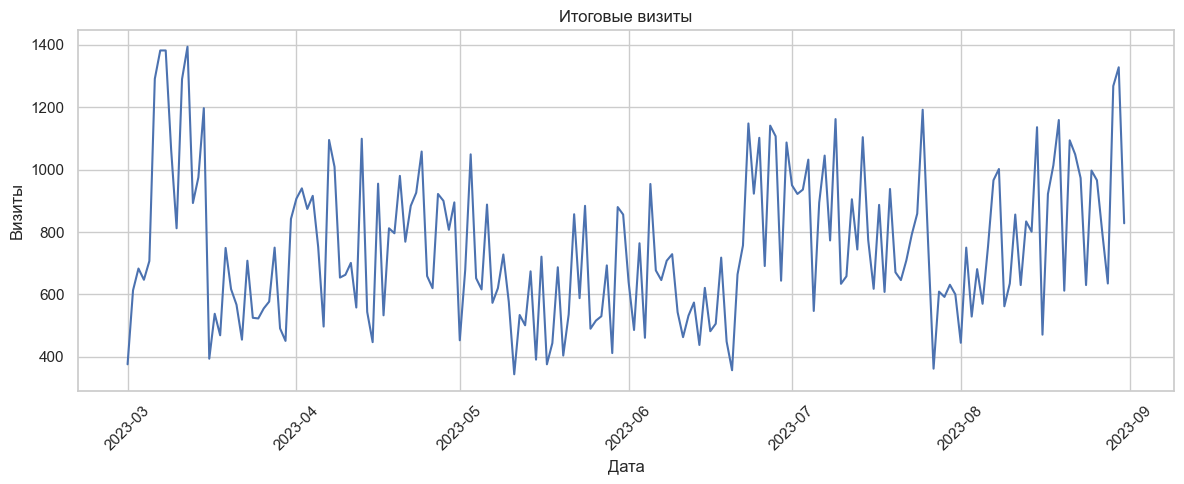

In [245]:
plt.figure(figsize=(12, 5))
plt.plot(df_final['date_group'], df_final['visits'])

plt.title('Итоговые визиты')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/total_visits.png', dpi=300)
plt.show()


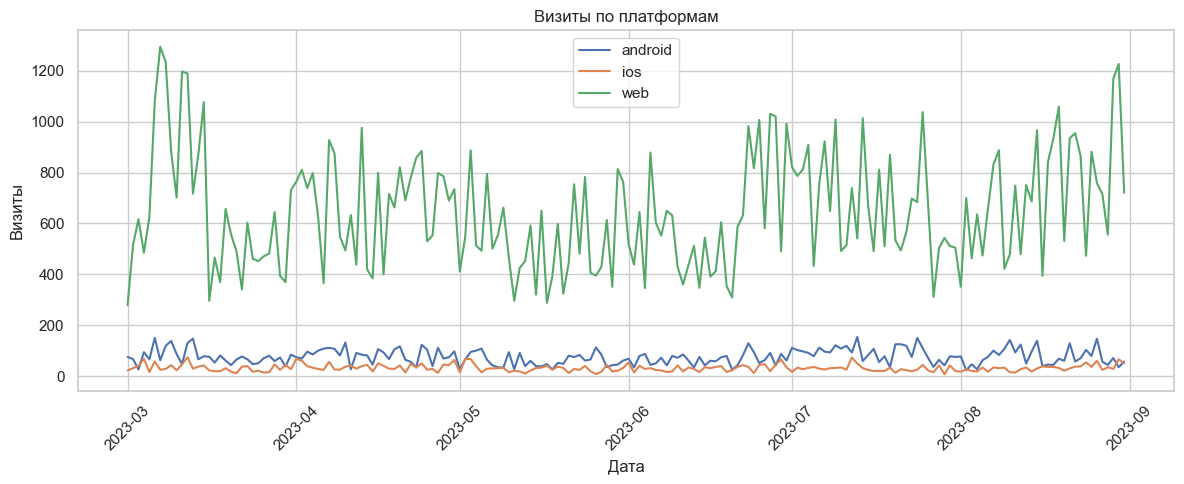

In [246]:
df_visits_platform = df.pivot(
    index='date_group',
    columns='platform',
    values='visits'
)

plt.figure(figsize=(12, 5))

for platform in df_visits_platform.columns:
    plt.plot(df_visits_platform.index, df_visits_platform[platform], label=platform)

plt.title('Визиты по платформам')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/visits_by_platform.png', dpi=300)
plt.show()


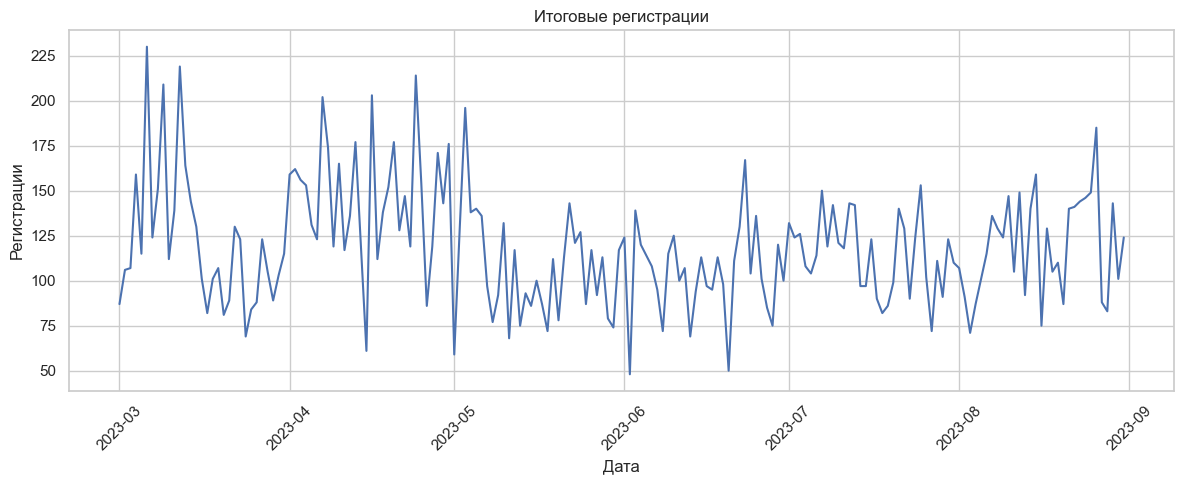

In [247]:
plt.figure(figsize=(12, 5))
plt.plot(df_final['date_group'], df_final['registrations'])

plt.title('Итоговые регистрации')
plt.xlabel('Дата')
plt.ylabel('Регистрации')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/total_registrations.png', dpi=300)
plt.show()


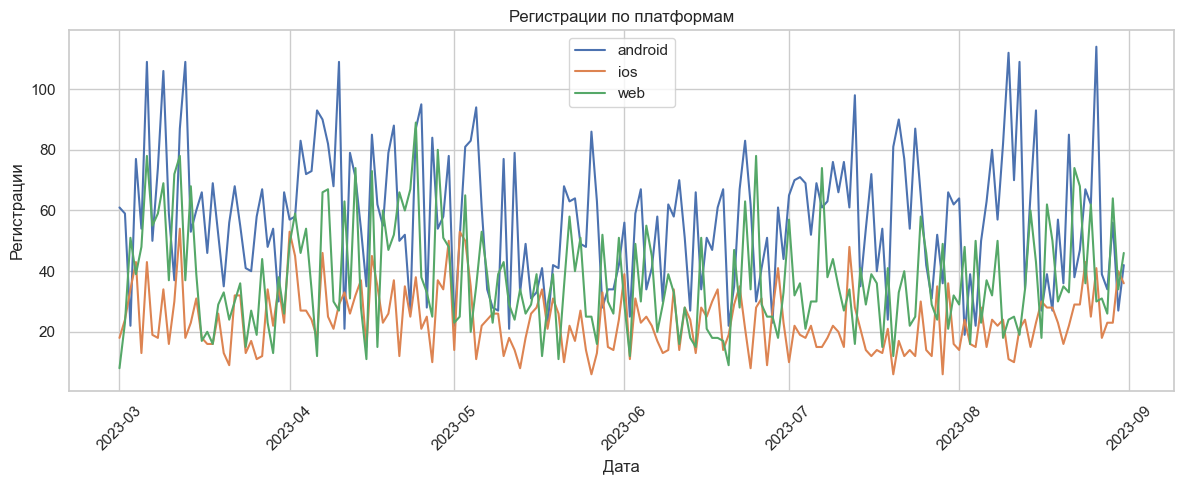

In [248]:
df_regs_platform = df.pivot(
    index='date_group',
    columns='platform',
    values='registrations'
)

plt.figure(figsize=(12, 5))

for platform in df_regs_platform.columns:
    plt.plot(df_regs_platform.index, df_regs_platform[platform], label=platform)

plt.title('Регистрации по платформам')
plt.xlabel('Дата')
plt.ylabel('Регистрации')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/registrations_by_platform.png', dpi=300)
plt.show()


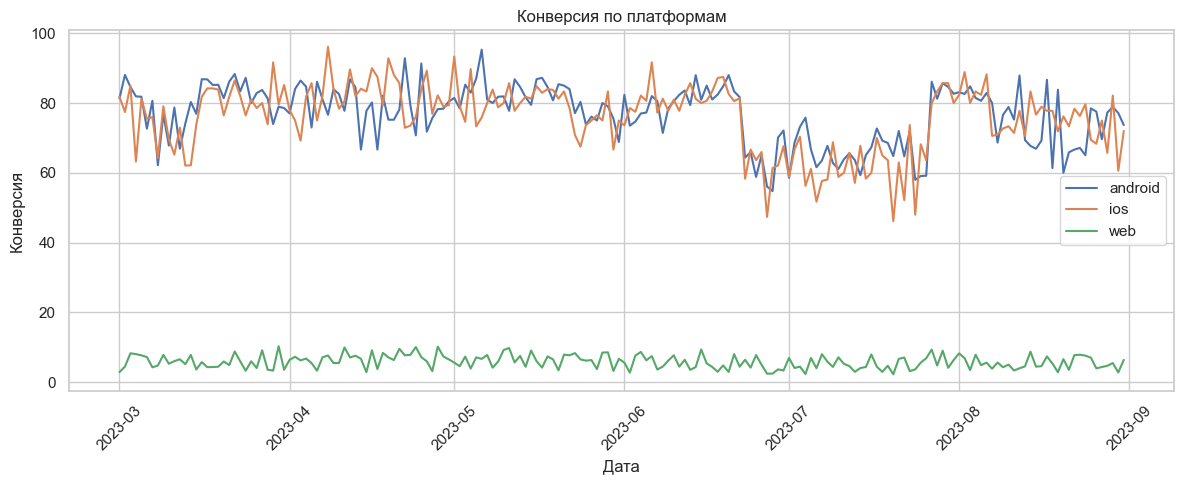

In [249]:
df_conversion_platform = df.pivot(
    index='date_group',
    columns='platform',
    values='conversion'
)

plt.figure(figsize=(12, 5))

for platform in df_conversion_platform.columns:
    plt.plot(df_conversion_platform.index, df_conversion_platform[platform], label=platform)

plt.title('Конверсия по платформам')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/conversion_by_platform.png', dpi=300)
plt.show()


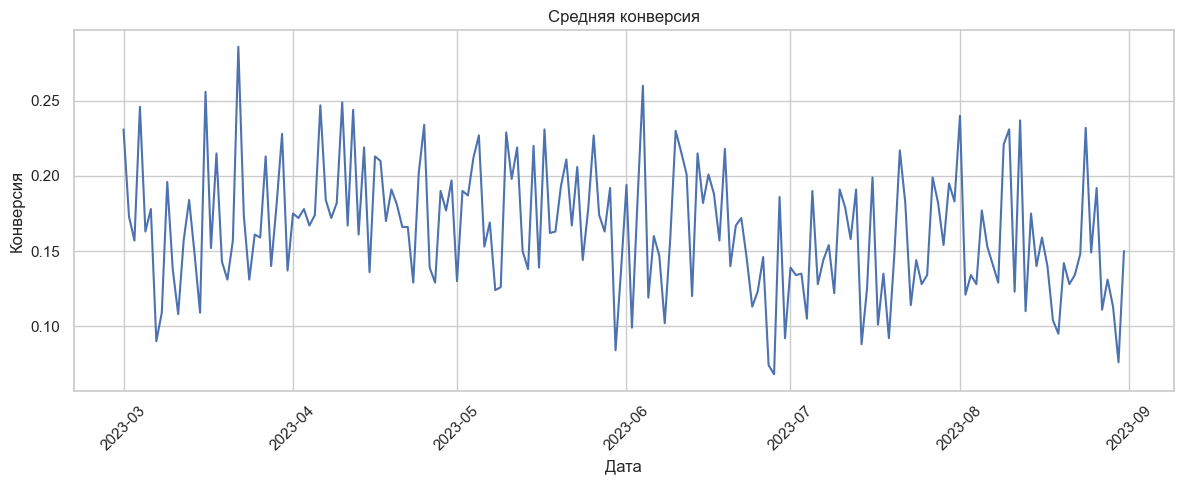

In [250]:
plt.figure(figsize=(12, 5))
plt.plot(df_final['date_group'], df_final['conversion'])

plt.title('Средняя конверсия')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/average_conversion.png', dpi=300)
plt.show()

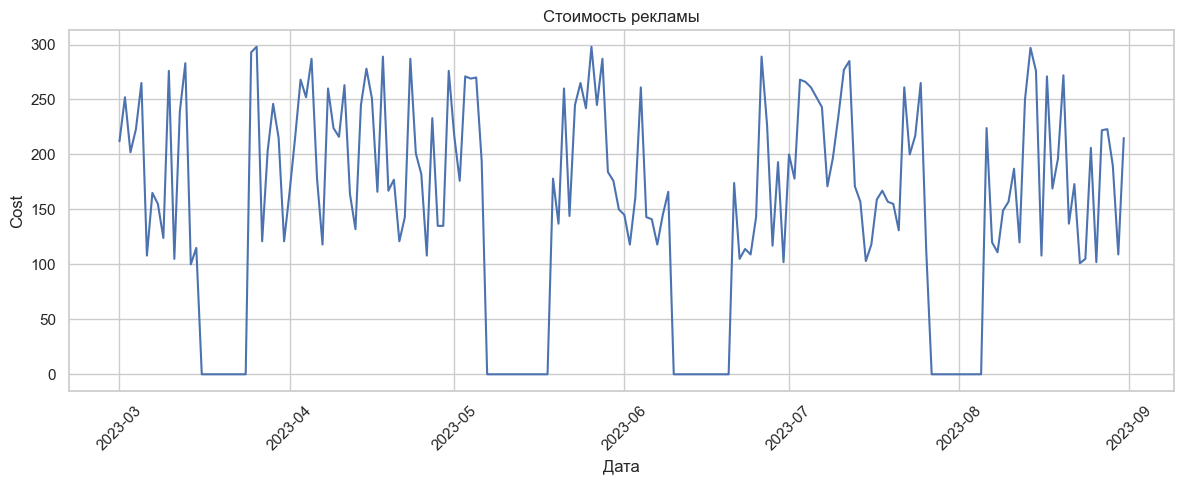

In [251]:
plt.figure(figsize=(12, 5))
plt.plot(df_final['date_group'], df_final['cost'])

plt.title('Стоимость рекламы')
plt.xlabel('Дата')
plt.ylabel('Cost')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/ads_cost.png', dpi=300)
plt.show()

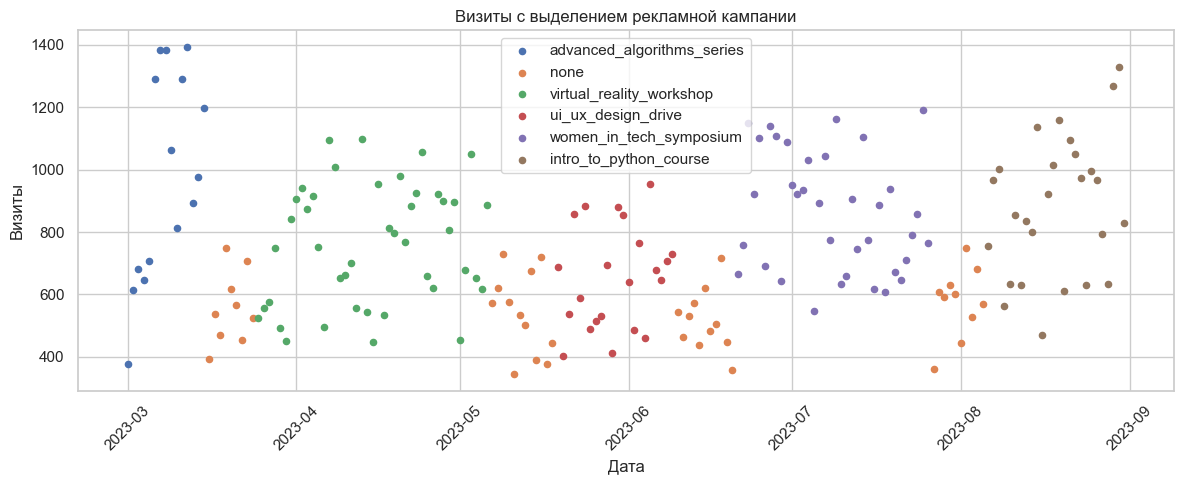

In [252]:
campaigns = df_final['utm_campaign'].unique()

plt.figure(figsize=(12, 5))

for campaign in campaigns:
    part = df_final[df_final['utm_campaign'] == campaign]
    plt.scatter(
        part['date_group'],
        part['visits'],
        label=campaign,
        s=20
    )

plt.title('Визиты с выделением рекламной кампании')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/visits_by_campaign.png', dpi=300)
plt.show()

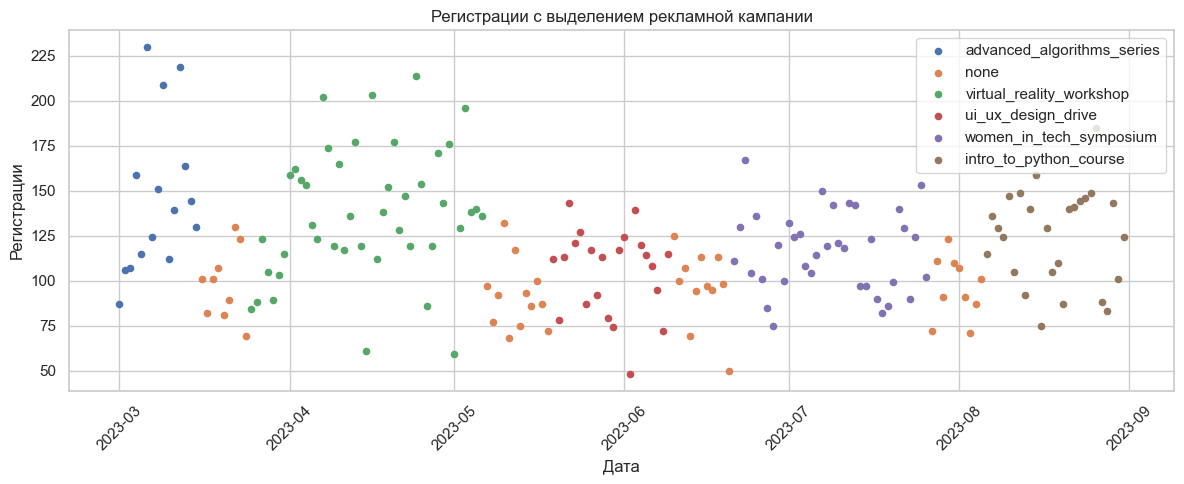

In [253]:
campaigns = df_final['utm_campaign'].unique()

plt.figure(figsize=(12, 5))

for campaign in campaigns:
    part = df_final[df_final['utm_campaign'] == campaign]
    plt.scatter(
        part['date_group'],
        part['registrations'],
        label=campaign,
        s=20
    )

plt.title('Регистрации с выделением рекламной кампании')
plt.xlabel('Дата')
plt.ylabel('Регистрации')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('charts/registrations_by_campaign.png', dpi=300)
plt.show()